## 2. Feature engineering and feature selection
In this part, the feature engineering process will be carried out. For this purpose, the distributions of variable data were compared to assess whether a variable requires transformation (the process is carried out only for numerical variables). Next, the feature selection process was carried out using selected methods in order to reject the least significant variables and create groups of variables that best explain the dependent variable.

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder
from sklearn import tree
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import f_regression
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from itertools import product
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif
from boruta import BorutaPy as bp
import os
from pmdarima.arima import auto_arima
import warnings

In [6]:
df = pd.read_csv('C:\\Users\\kubas\\OneDrive\\Documents\\ML2\\ProjectClassification\\data_cleaned.csv')
df_test = pd.read_csv('C:\\Users\\kubas\\OneDrive\\Documents\\ML2\\ProjectClassification\\data_test_cleaned.csv')

In [8]:
df

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,...,is_power_steering_No,is_power_steering_Yes,is_driver_seat_height_adjustable_No,is_driver_seat_height_adjustable_Yes,is_day_night_rear_view_mirror_No,is_day_night_rear_view_mirror_Yes,is_ecw_No,is_ecw_Yes,is_speed_alert_No,is_speed_alert_Yes
0,11.6,1.6,58,27003,2,1197,4,4.8,3845,1735,...,False,True,False,True,False,True,False,True,False,True
1,5.7,0.2,43,4076,2,796,3,4.6,3445,1515,...,False,True,True,False,True,False,True,False,False,True
2,11.5,3.2,38,7788,2,1197,4,4.8,3845,1735,...,False,True,False,True,False,True,False,True,False,True
3,2.7,2.0,39,73430,2,1197,4,4.8,3845,1735,...,False,True,False,True,False,True,False,True,False,True
4,10.5,1.6,45,73430,2,1197,4,4.8,3845,1735,...,False,True,False,True,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46868,10.3,1.0,43,5410,2,1197,4,4.8,3845,1735,...,False,True,False,True,False,True,False,True,False,True
46869,3.6,3.2,42,17804,2,1197,4,4.8,3845,1735,...,False,True,False,True,False,True,False,True,False,True
46870,11.8,2.6,54,27003,2,796,3,4.6,3445,1515,...,False,True,True,False,True,False,True,False,False,True
46871,7.5,2.6,48,8794,2,1197,4,4.8,3845,1735,...,False,True,False,True,False,True,False,True,False,True


### Feature engeenering - numerical variables

All features

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46873 entries, 0 to 46872
Data columns (total 92 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   subscription_length                   46873 non-null  float64
 1   vehicle_age                           46873 non-null  float64
 2   customer_age                          46873 non-null  int64  
 3   region_density                        46873 non-null  int64  
 4   airbags                               46873 non-null  int64  
 5   displacement                          46873 non-null  int64  
 6   cylinder                              46873 non-null  int64  
 7   turning_radius                        46873 non-null  float64
 8   length                                46873 non-null  int64  
 9   width                                 46873 non-null  int64  
 10  gross_weight                          46873 non-null  int64  
 11  ncap_rating    

##### subscription_length

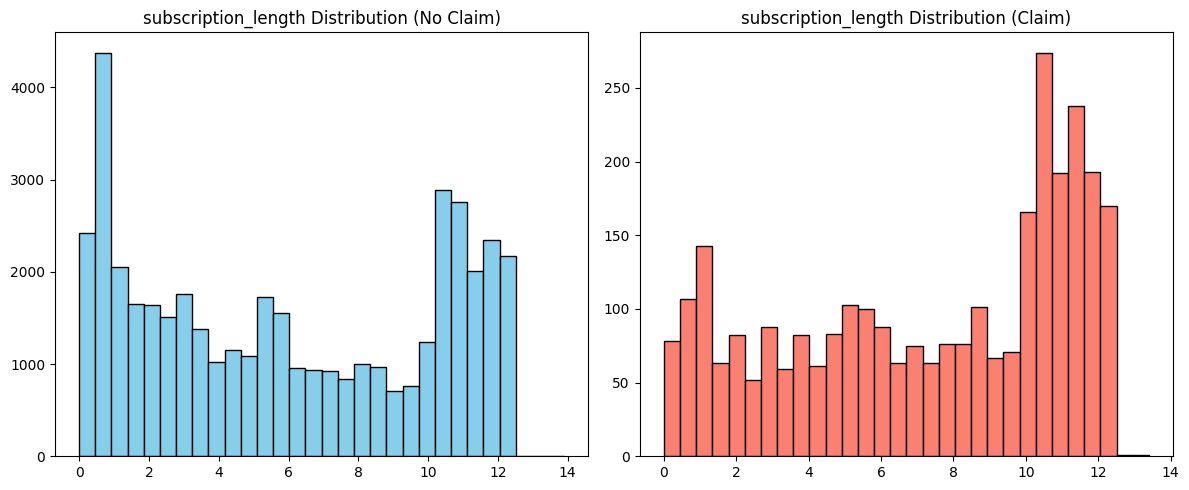

In [11]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['subscription_length'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('subscription_length Distribution (No Claim)')


axes[1].hist(df_1['subscription_length'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('subscription_length Distribution (Claim)')


plt.tight_layout()
plt.show()

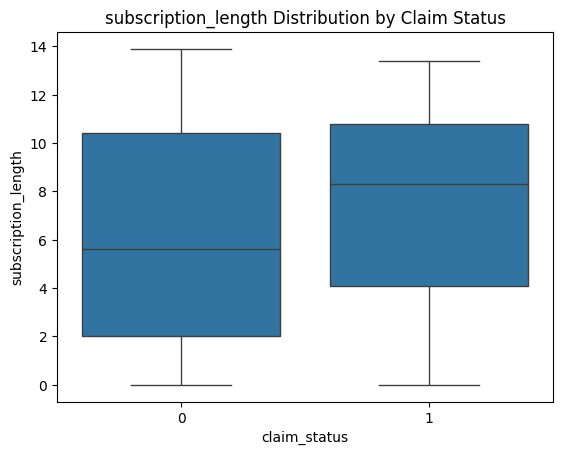

In [17]:
sns.boxplot(x='claim_status', y='subscription_length', data=df)
plt.title('subscription_length Distribution by Claim Status')
plt.show()

In [96]:
df["subscription_length_sqrt"] = np.sqrt(df.subscription_length)
df_test["subscription_length_sqrt"] = np.sqrt(df_test.subscription_length)

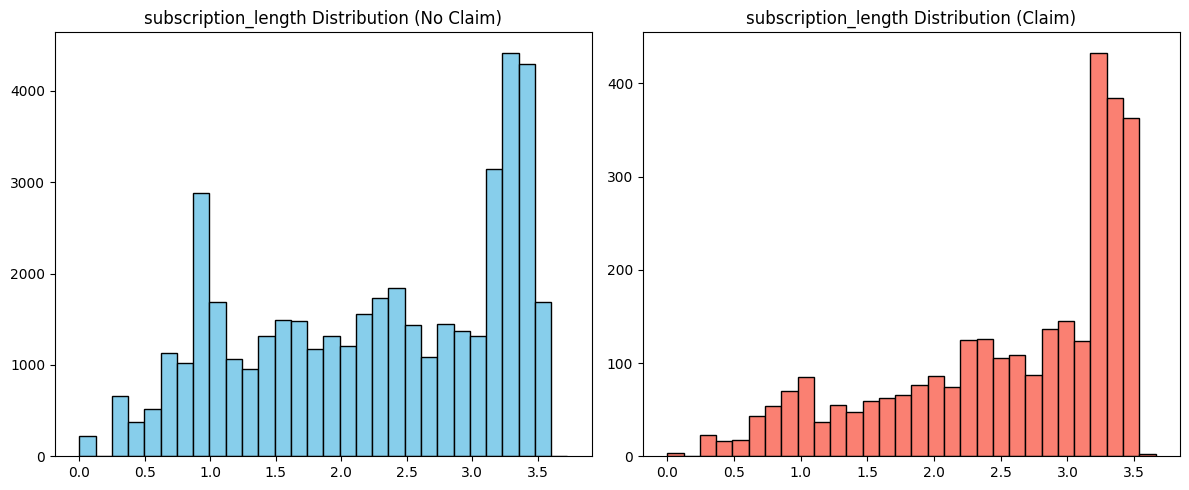

In [97]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['subscription_length_sqrt'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('subscription_length Distribution (No Claim)')


axes[1].hist(df_1['subscription_length_sqrt'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('subscription_length Distribution (Claim)')


plt.tight_layout()
plt.show()

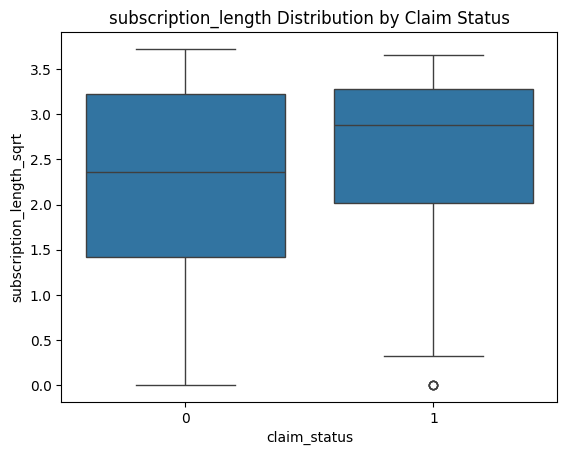

In [98]:
sns.boxplot(x='claim_status', y='subscription_length_sqrt', data=df)
plt.title('subscription_length Distribution by Claim Status')
plt.show()

#### vehicle_age

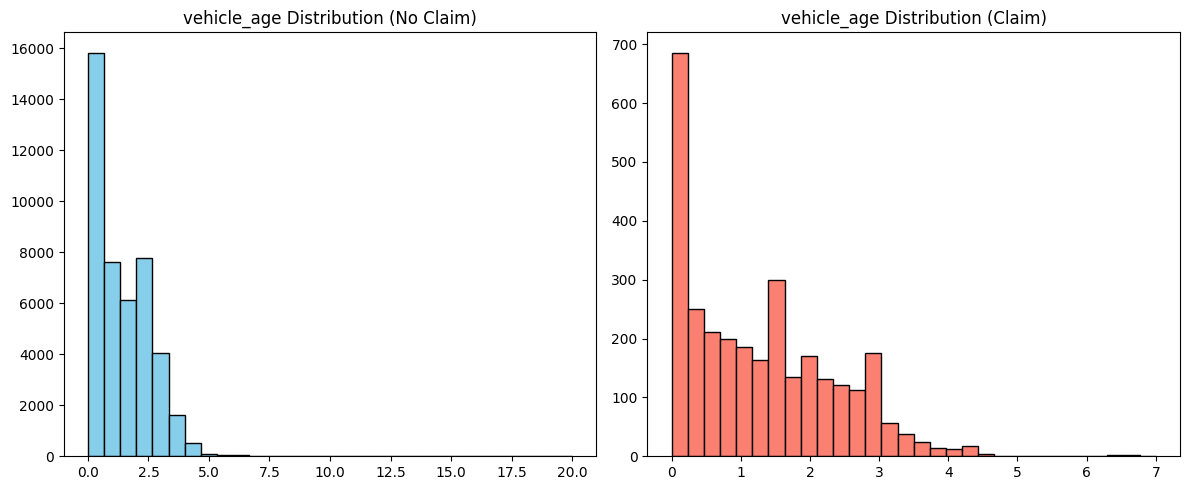

In [15]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['vehicle_age'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('vehicle_age Distribution (No Claim)')


axes[1].hist(df_1['vehicle_age'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('vehicle_age Distribution (Claim)')


plt.tight_layout()
plt.show()

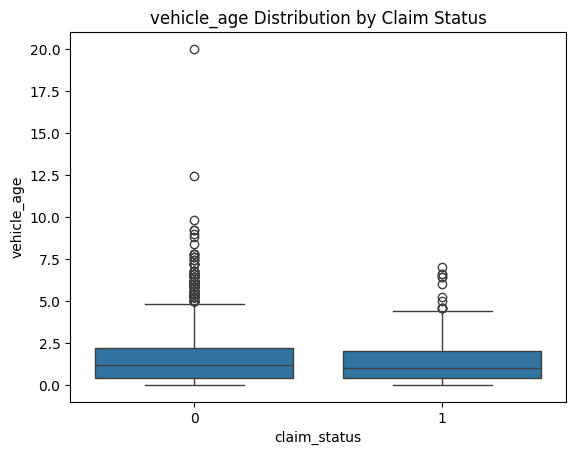

In [18]:
sns.boxplot(x='claim_status', y='vehicle_age', data=df)
plt.title('vehicle_age Distribution by Claim Status')
plt.show()

In [19]:
df_temp = df.copy()

In [45]:
df_temp.vehicle_age.quantile(0.99)

np.float64(4.2)

In [46]:
df_temp["vehicle_age_cut"] = df_temp.vehicle_age.clip(upper=df_temp.vehicle_age.quantile(0.99))

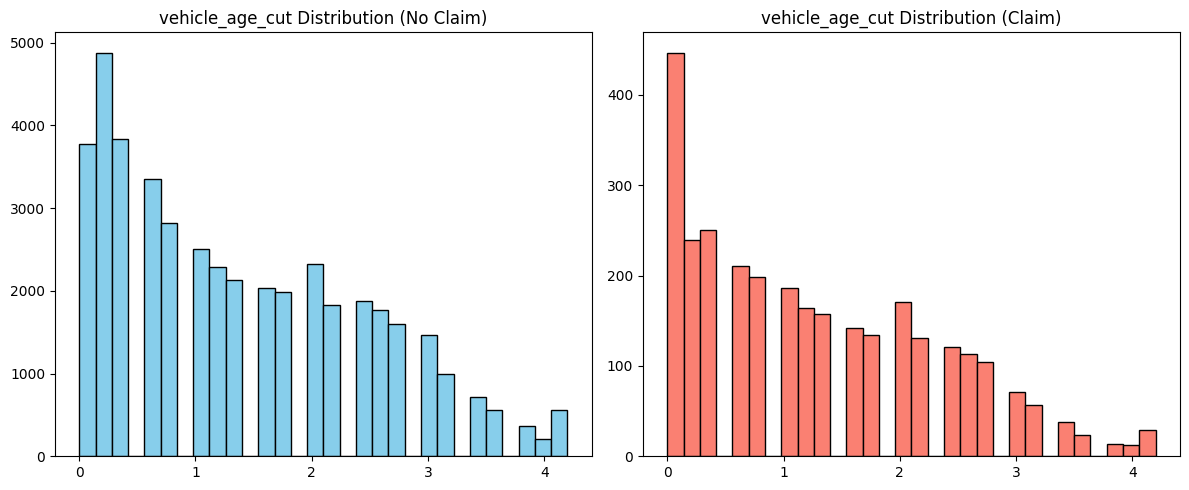

In [49]:
df_0 = df_temp[df_temp['claim_status'] == 0]
df_1 = df_temp[df_temp['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['vehicle_age_cut'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('vehicle_age_cut Distribution (No Claim)')


axes[1].hist(df_1['vehicle_age_cut'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('vehicle_age_cut Distribution (Claim)')


plt.tight_layout()
plt.show()

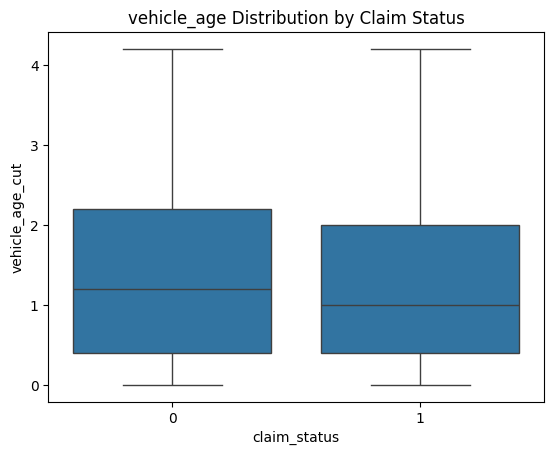

In [48]:
sns.boxplot(x='claim_status', y='vehicle_age_cut', data=df_temp)
plt.title('vehicle_age Distribution by Claim Status')
plt.show()

In [50]:
df["vehicle_age_cut"] = df.vehicle_age.clip(upper=df.vehicle_age.quantile(0.99))
df_test["vehicle_age_cut"] = df_test.vehicle_age.clip(upper=df_test.vehicle_age.quantile(0.99))

#### customer_age

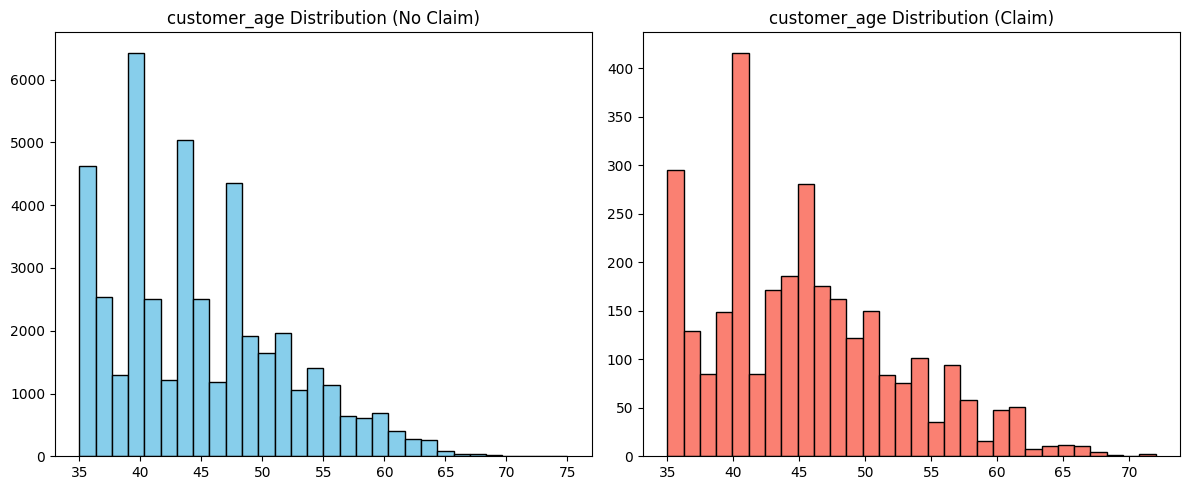

In [51]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['customer_age'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('customer_age Distribution (No Claim)')


axes[1].hist(df_1['customer_age'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('customer_age Distribution (Claim)')


plt.tight_layout()
plt.show()

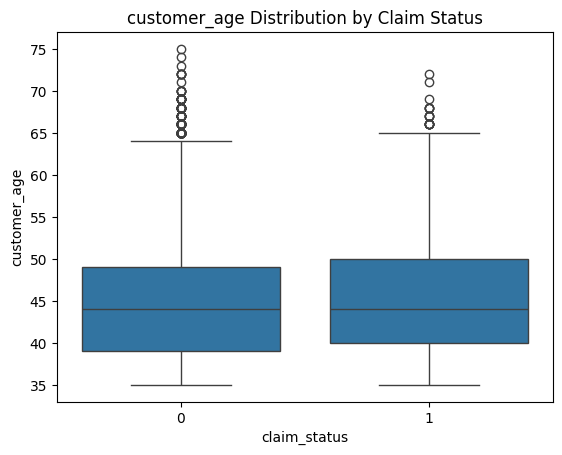

In [57]:
sns.boxplot(x='claim_status', y='customer_age', data=df)
plt.title('customer_age Distribution by Claim Status')
plt.show()

In [53]:
df["customer_age_log"] = np.log(df.customer_age)
df_test["customer_age_log"] = np.log(df_test.customer_age)

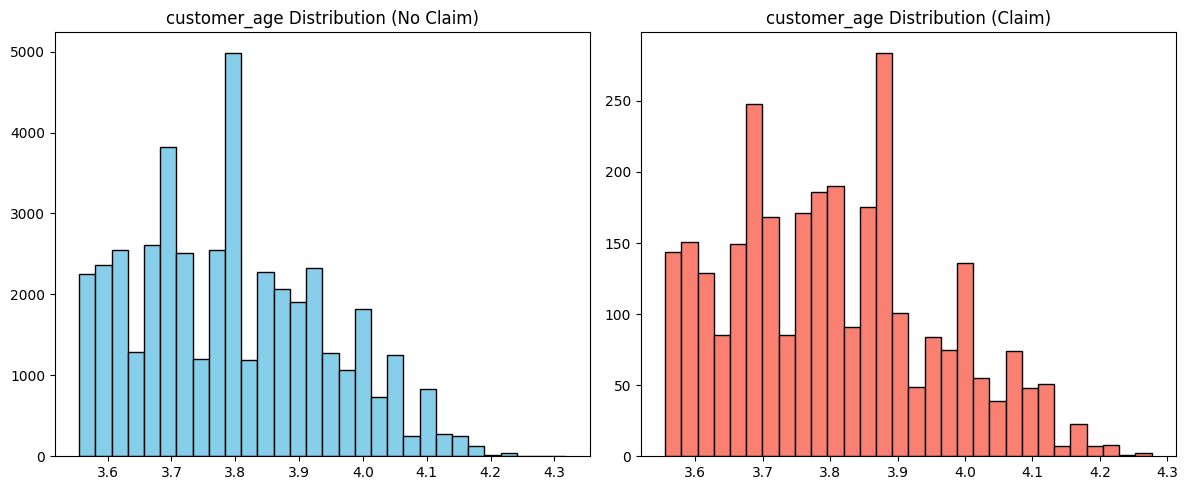

In [54]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['customer_age_log'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('customer_age Distribution (No Claim)')


axes[1].hist(df_1['customer_age_log'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('customer_age Distribution (Claim)')


plt.tight_layout()
plt.show()

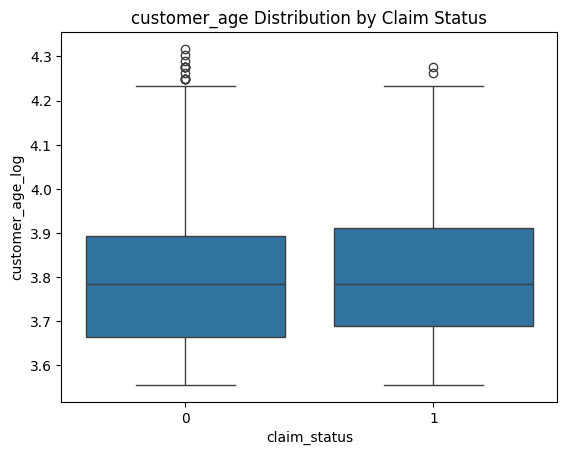

In [56]:
sns.boxplot(x='claim_status', y='customer_age_log', data=df)
plt.title('customer_age Distribution by Claim Status')
plt.show()

#### region_density 

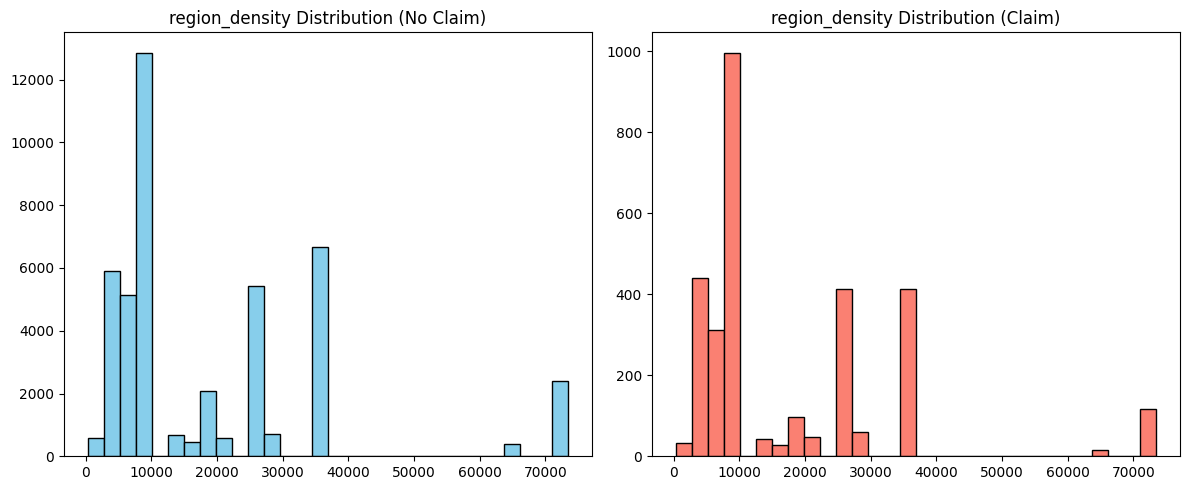

In [58]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['region_density'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('region_density Distribution (No Claim)')


axes[1].hist(df_1['region_density'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('region_density Distribution (Claim)')


plt.tight_layout()
plt.show()

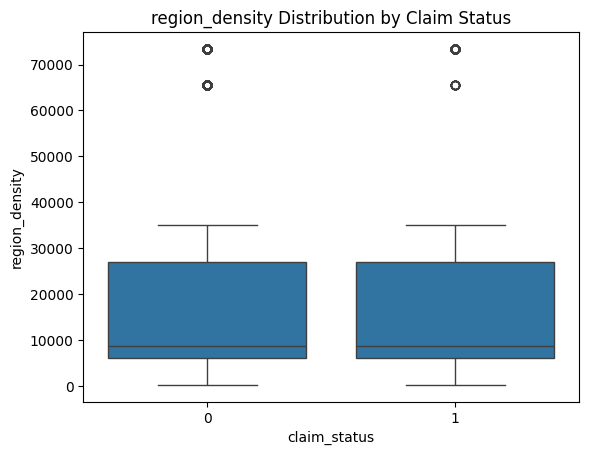

In [60]:
sns.boxplot(x='claim_status', y='region_density', data=df)
plt.title('region_density Distribution by Claim Status')
plt.show()

In [66]:
df["region_density_sqrt"] = np.sqrt(df.region_density)
df_test["region_density_sqrt"] = np.sqrt(df_test.region_density)

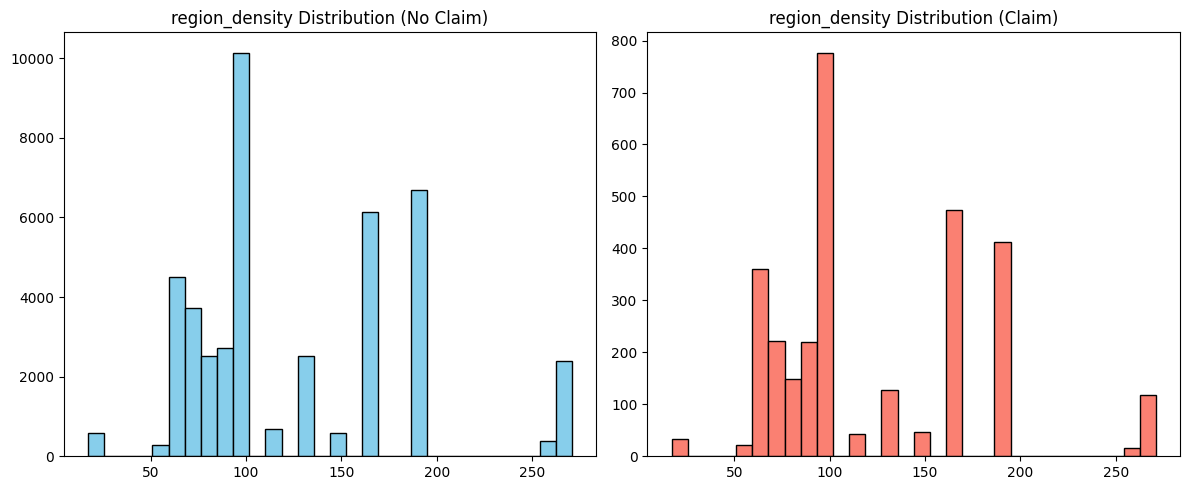

In [67]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['region_density_sqrt'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('region_density Distribution (No Claim)')


axes[1].hist(df_1['region_density_sqrt'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('region_density Distribution (Claim)')


plt.tight_layout()
plt.show()

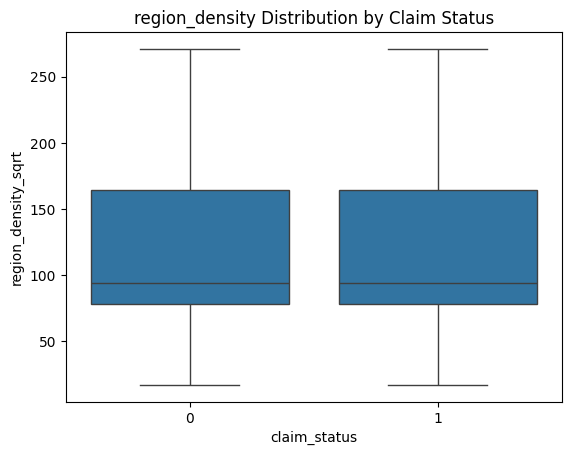

In [68]:
sns.boxplot(x='claim_status', y='region_density_sqrt', data=df)
plt.title('region_density Distribution by Claim Status')
plt.show()

#### airbags

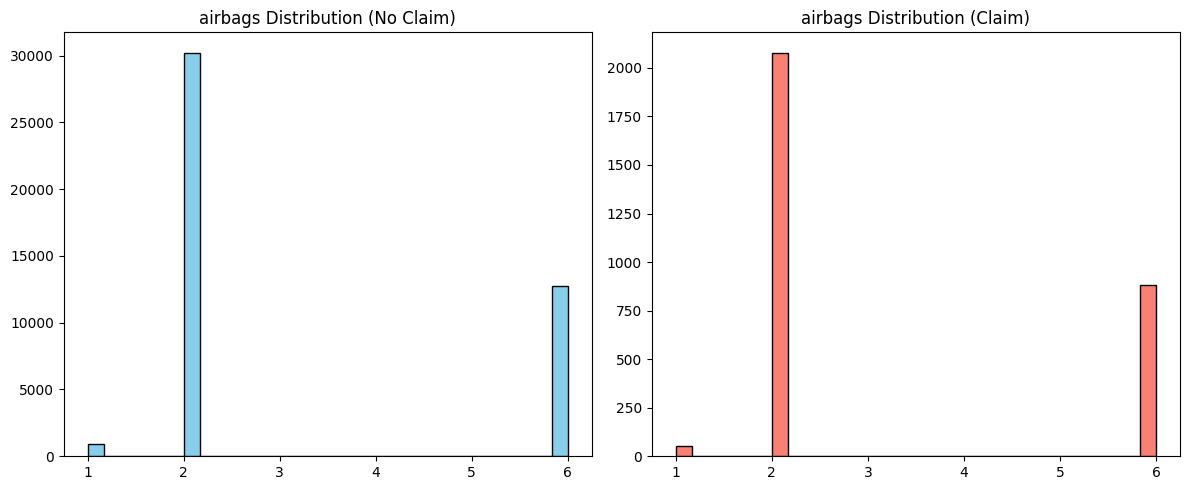

In [70]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['airbags'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('airbags Distribution (No Claim)')


axes[1].hist(df_1['airbags'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('airbags Distribution (Claim)')


plt.tight_layout()
plt.show()

Looks like ordinal variable -> there is no need to change it

#### displacement

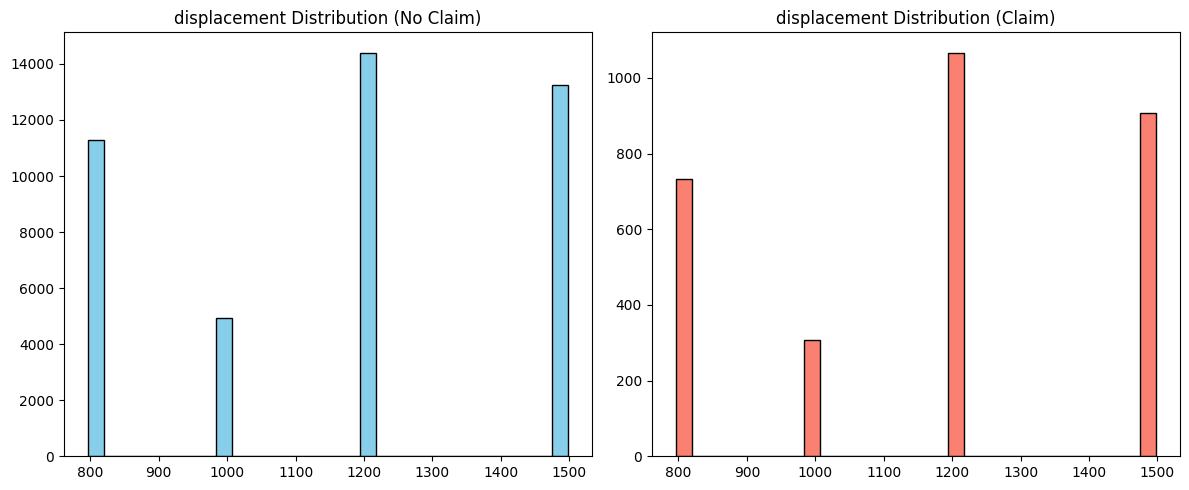

In [71]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['displacement'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('displacement Distribution (No Claim)')


axes[1].hist(df_1['displacement'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('displacement Distribution (Claim)')


plt.tight_layout()
plt.show()

Looks like ordinal variable -> there is no need to change it

#### cylinder

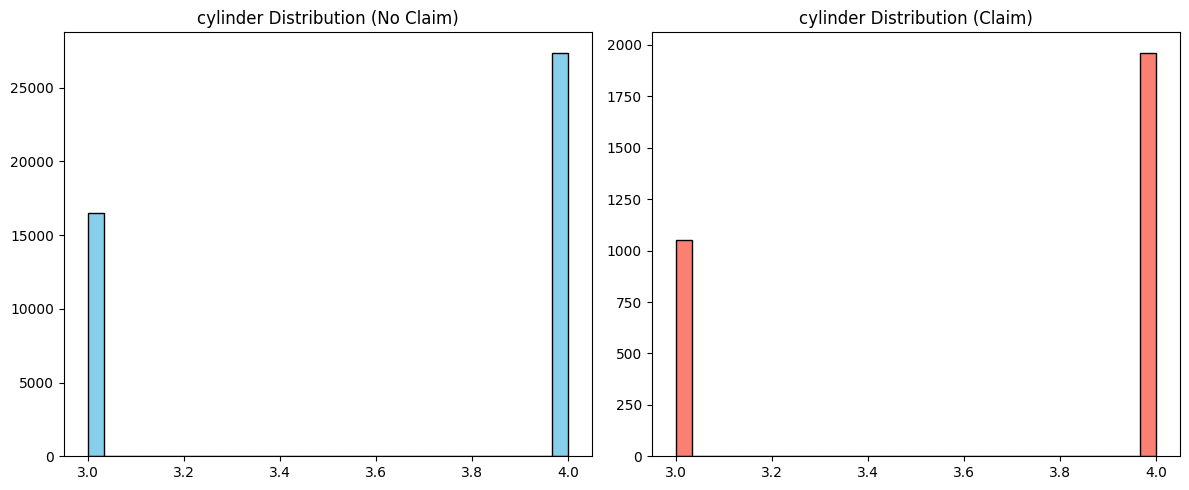

In [72]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['cylinder'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('cylinder Distribution (No Claim)')


axes[1].hist(df_1['cylinder'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('cylinder Distribution (Claim)')


plt.tight_layout()
plt.show()

Looks like ordinal variable -> there is no need to change it

#### turning_radius

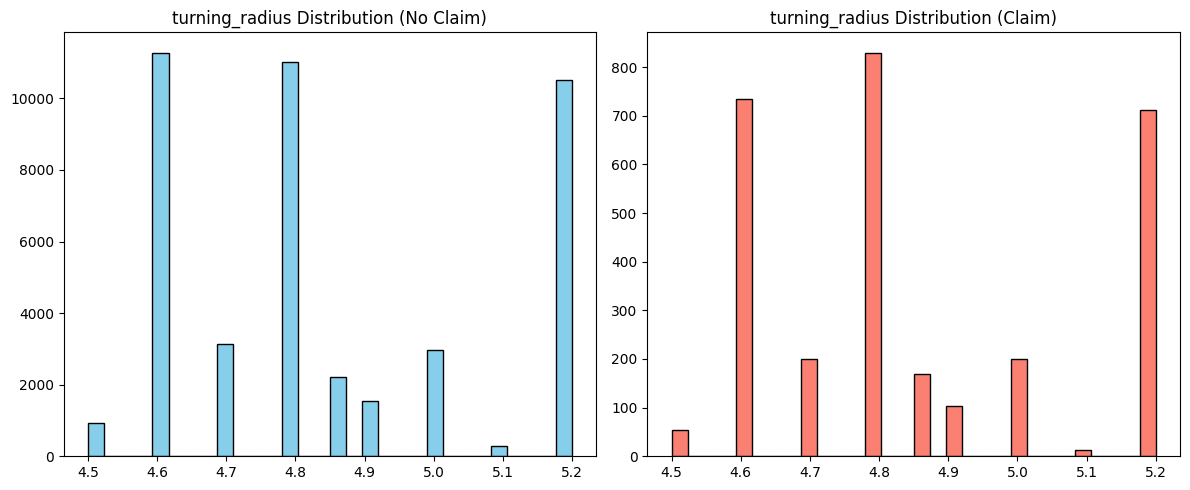

In [73]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['turning_radius'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('turning_radius Distribution (No Claim)')


axes[1].hist(df_1['turning_radius'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('turning_radius Distribution (Claim)')


plt.tight_layout()
plt.show()

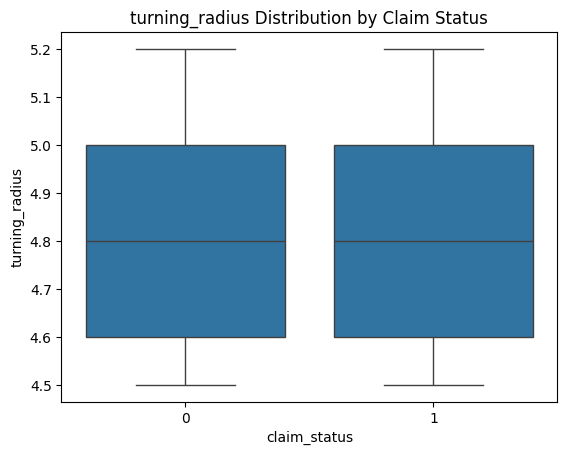

In [75]:
sns.boxplot(x='claim_status', y='turning_radius', data=df)
plt.title('turning_radius Distribution by Claim Status')
plt.show()

Also no need to change this variable

#### length

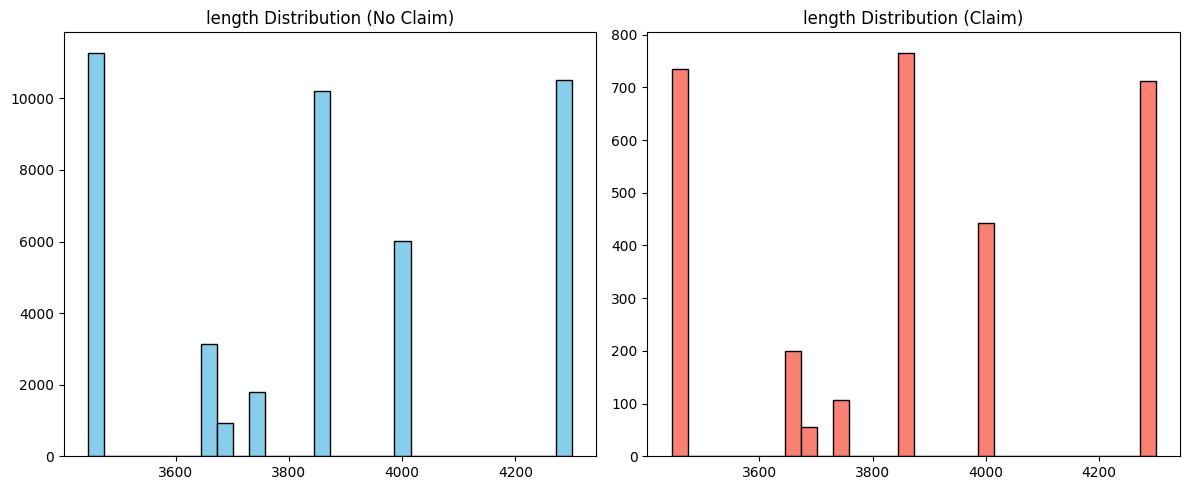

In [78]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['length'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('length Distribution (No Claim)')


axes[1].hist(df_1['length'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('length Distribution (Claim)')


plt.tight_layout()
plt.show()

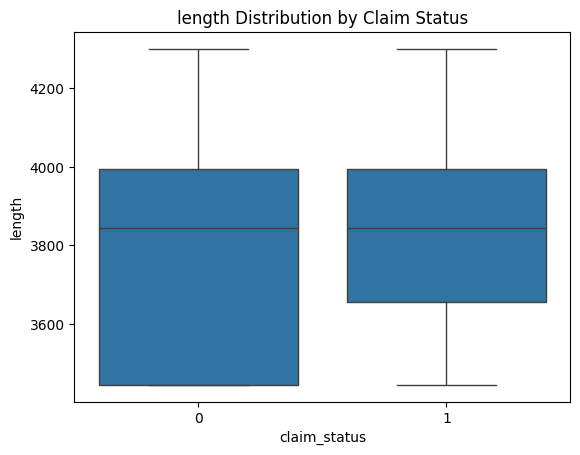

In [79]:
sns.boxplot(x='claim_status', y='length', data=df)
plt.title('length Distribution by Claim Status')
plt.show()

Also no need to change this variable

#### width

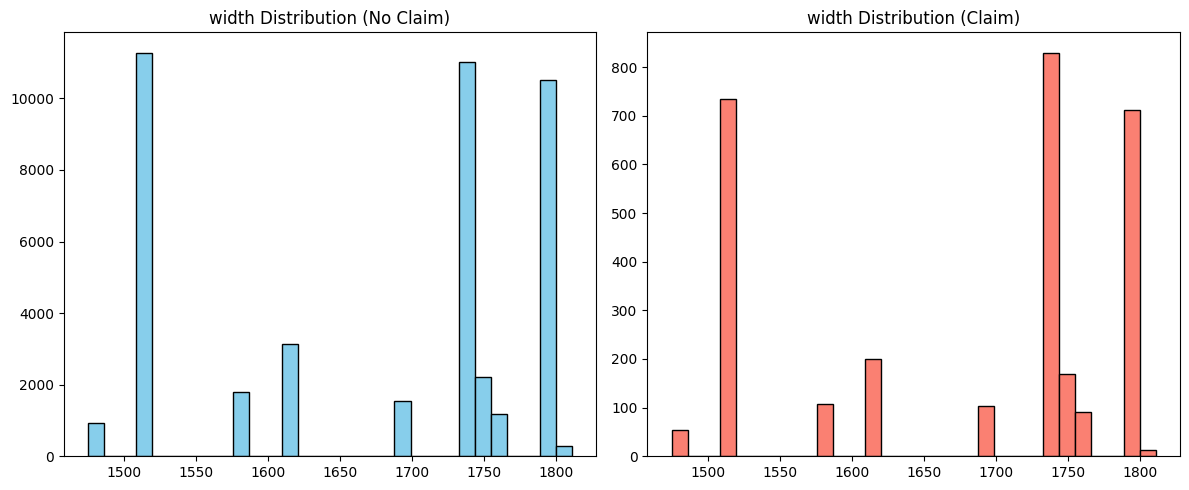

In [80]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['width'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('width Distribution (No Claim)')


axes[1].hist(df_1['width'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('width Distribution (Claim)')


plt.tight_layout()
plt.show()

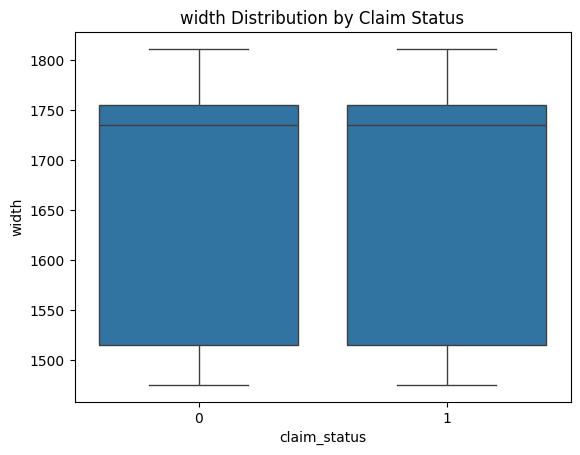

In [81]:
sns.boxplot(x='claim_status', y='width', data=df)
plt.title('width Distribution by Claim Status')
plt.show()

Also no need to change this variable

#### gross_weight

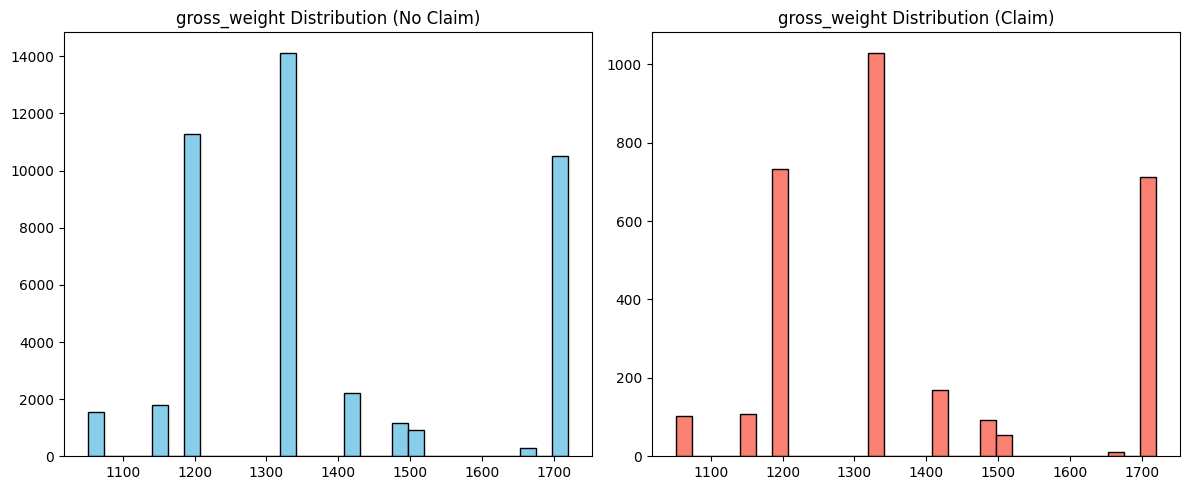

In [83]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['gross_weight'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('gross_weight Distribution (No Claim)')


axes[1].hist(df_1['gross_weight'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('gross_weight Distribution (Claim)')


plt.tight_layout()
plt.show()

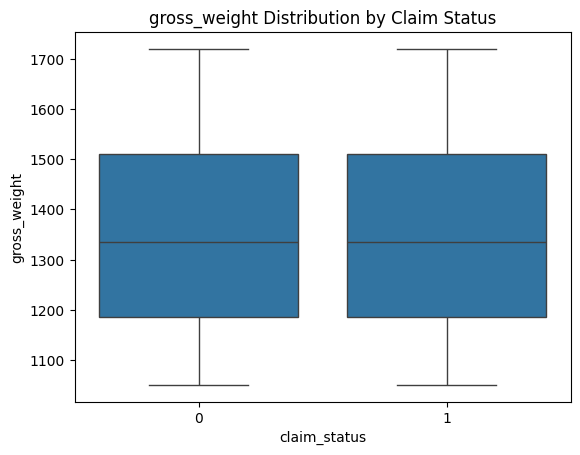

In [84]:
sns.boxplot(x='claim_status', y='gross_weight', data=df)
plt.title('gross_weight Distribution by Claim Status')
plt.show()

Also no need to change this variable

##### As we can see, although the four variables above are continuous variables, they only take on a finite number of values, which makes them more similar to discrete variables. This type of variable is very good for decision tree models, so there is no reason to modify them in feature engineering process.

#### ncap_rating

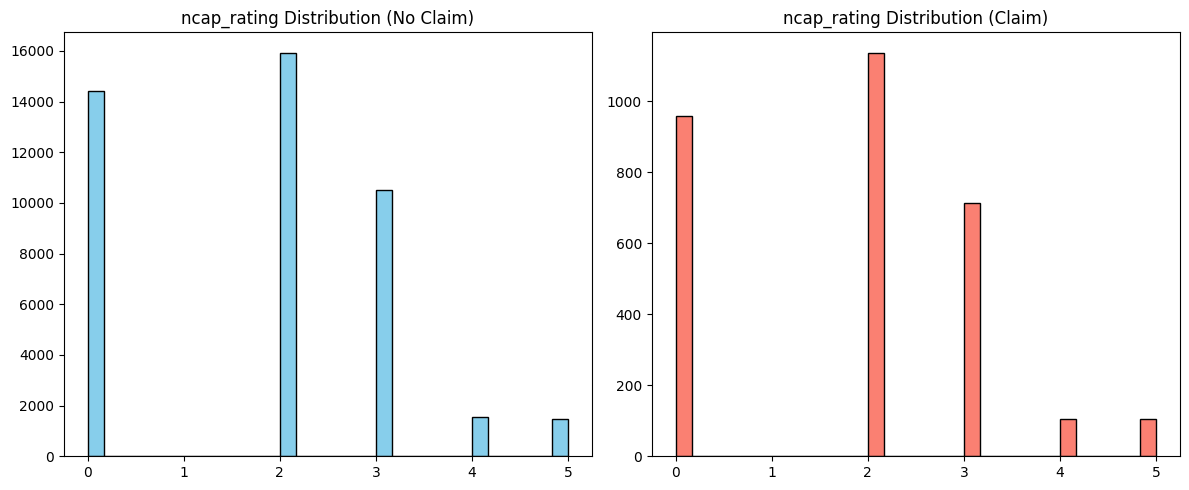

In [86]:
df_0 = df[df['claim_status'] == 0]
df_1 = df[df['claim_status'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_0['ncap_rating'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('ncap_rating Distribution (No Claim)')


axes[1].hist(df_1['ncap_rating'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('ncap_rating Distribution (Claim)')


plt.tight_layout()
plt.show()

Looks like ordinal variable -> there is no need to change it

#### Saving our modified datasets

In [99]:
print(df.shape, df_test.shape)

(46873, 96) (11719, 96)


In [101]:
df.columns

Index(['subscription_length', 'vehicle_age', 'customer_age', 'region_density',
       'airbags', 'displacement', 'cylinder', 'turning_radius', 'length',
       'width', 'gross_weight', 'ncap_rating', 'claim_status', 'segment_A',
       'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2',
       'segment_Utility', 'model_M1', 'model_M10', 'model_M11', 'model_M2',
       'model_M3', 'model_M4', 'model_M5', 'model_M6', 'model_M7', 'model_M8',
       'model_M9', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Petrol',
       'max_torque_113Nm@4400rpm', 'max_torque_170Nm@4000rpm',
       'max_torque_200Nm@1750rpm', 'max_torque_200Nm@3000rpm',
       'max_torque_250Nm@2750rpm', 'max_torque_60Nm@3500rpm',
       'max_torque_82.1Nm@3400rpm', 'max_torque_85Nm@3000rpm',
       'max_torque_91Nm@4250rpm', 'max_power_113.45bhp@4000rpm',
       'max_power_118.36bhp@5500rpm', 'max_power_40.36bhp@6000rpm',
       'max_power_55.92bhp@5300rpm', 'max_power_61.68bhp@6000rpm',
       'max_power_67.06bhp

In [102]:
df.to_csv("train_fe.csv", index=False)
df_test.to_csv("test_fe.csv", index=False)

### Feature selection
The following selection methods were chosen in the feature selection process:
* Variance Threshold
* F-test
* Correlation - Spearman
* Mutal Information
* Elastic Net
* Boruta

In [103]:
x_col = ['subscription_length', 'vehicle_age', 'customer_age', 'region_density',
       'airbags', 'displacement', 'cylinder', 'turning_radius', 'length',
       'width', 'gross_weight', 'ncap_rating', 'segment_A',
       'segment_B1', 'segment_B2', 'segment_C1', 'segment_C2',
       'segment_Utility', 'model_M1', 'model_M10', 'model_M11', 'model_M2',
       'model_M3', 'model_M4', 'model_M5', 'model_M6', 'model_M7', 'model_M8',
       'model_M9', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Petrol',
       'max_torque_113Nm@4400rpm', 'max_torque_170Nm@4000rpm',
       'max_torque_200Nm@1750rpm', 'max_torque_200Nm@3000rpm',
       'max_torque_250Nm@2750rpm', 'max_torque_60Nm@3500rpm',
       'max_torque_82.1Nm@3400rpm', 'max_torque_85Nm@3000rpm',
       'max_torque_91Nm@4250rpm', 'max_power_113.45bhp@4000rpm',
       'max_power_118.36bhp@5500rpm', 'max_power_40.36bhp@6000rpm',
       'max_power_55.92bhp@5300rpm', 'max_power_61.68bhp@6000rpm',
       'max_power_67.06bhp@5500rpm', 'max_power_88.50bhp@6000rpm',
       'max_power_88.77bhp@4000rpm', 'max_power_97.89bhp@3600rpm', 'is_esc_No',
       'is_esc_Yes', 'is_adjustable_steering_No', 'is_adjustable_steering_Yes',
       'is_tpms_No', 'is_tpms_Yes', 'is_parking_sensors_No',
       'is_parking_sensors_Yes', 'is_parking_camera_No',
       'is_parking_camera_Yes', 'rear_brakes_type_Disc',
       'rear_brakes_type_Drum', 'transmission_type_Automatic',
       'transmission_type_Manual', 'steering_type_Electric',
       'steering_type_Manual', 'steering_type_Power', 'is_front_fog_lights_No',
       'is_front_fog_lights_Yes', 'is_rear_window_wiper_No',
       'is_rear_window_wiper_Yes', 'is_rear_window_washer_No',
       'is_rear_window_washer_Yes', 'is_rear_window_defogger_No',
       'is_rear_window_defogger_Yes', 'is_brake_assist_No',
       'is_brake_assist_Yes', 'is_power_door_locks_No',
       'is_power_door_locks_Yes', 'is_central_locking_No',
       'is_central_locking_Yes', 'is_power_steering_No',
       'is_power_steering_Yes', 'is_driver_seat_height_adjustable_No',
       'is_driver_seat_height_adjustable_Yes',
       'is_day_night_rear_view_mirror_No', 'is_day_night_rear_view_mirror_Yes',
       'is_ecw_No', 'is_ecw_Yes', 'is_speed_alert_No', 'is_speed_alert_Yes',
       'vehicle_age_cut', 'customer_age_log', 'region_density_sqrt',
       'subscription_length_sqrt']

In [104]:
y_col = 'claim_status'

In [105]:
general_ranking = pd.DataFrame(index=x_col)

#### Variance Threshold

In [106]:
# It deleates all variables with variance lower than chosen threshold. Features with low variance do not carry much information for our ML models.
sel = VarianceThreshold(0.05)
sel_var = sel.fit_transform(df[x_col])
col_imp = df[x_col][df[x_col].columns[sel.get_support(indices=True)]].columns
col_redundant = set(df[x_col].columns.tolist()) - set(col_imp)

#### F-test

In [109]:
warnings.simplefilter(action="ignore", category=FutureWarning)
fscore = {
    col: f_classif(df[[col]].values, df[y_col].values)[1][0]  # p-value
    for col in x_col
}

In [110]:
fscoreDF = pd.DataFrame.from_dict(fscore, orient="index", columns=["p_value_score"])

In [183]:
fscoreDF.sort_values(by="p_value_score", ascending=True).head(10)

,p_value_score,sign
subscription_length_sqrt,2.098944e-69,1
subscription_length,8.854852e-68,1
vehicle_age,1.370705e-07,1
vehicle_age_cut,1.538931e-07,1
customer_age,1.406965e-06,1
customer_age_log,1.767524e-06,1
region_density,1.342246e-05,1
region_density_sqrt,1.255060e-04,1
segment_B2,4.098030e-04,1
max_torque_113Nm@4400rpm,4.639111e-04,1


In [114]:
fscoreDF["sign"] = np.where(fscoreDF.p_value_score < 0.05, 1, 0)

In [116]:
general_ranking = pd.merge(general_ranking, fscoreDF, left_index=True, right_index=True)

In [117]:
general_ranking.rename(
    columns={"p_value_score": "sign_fscore", "sign": "sign_fscore_0_1"}, inplace=True
)

#### Correlation - Spearman

In [118]:
corr = list()
for i in x_col:
    corr.append(stats.spearmanr(df.loc[:, y_col].values, df.loc[:, i].values)[0])

In [120]:
general_ranking = pd.merge(
    general_ranking,
    pd.DataFrame(corr, index=x_col, columns=["corr"]),
    left_index=True,
    right_index=True,
)

#### Mutal Information
It measures how much information one variable provides about another - taret variable

In [122]:
from sklearn.feature_selection import mutual_info_classif

mi = {
    col: mutual_info_classif(df[[col]].values, df[y_col].values, discrete_features='auto')[0]
    for col in x_col
}

In [123]:
miDF = pd.DataFrame.from_dict(mi, orient="index", columns=["score"])

In [124]:
miDF.sort_values(by="score", ascending=False).head(10)

,score
is_parking_sensors_Yes,0.010967
is_esc_No,0.009386
is_rear_window_wiper_No,0.009211
is_day_night_rear_view_mirror_No,0.009146
is_ecw_Yes,0.009132
is_front_fog_lights_Yes,0.009077
is_central_locking_Yes,0.008920
is_tpms_No,0.008642
is_rear_window_defogger_No,0.008390
is_parking_camera_No,0.008192


In [125]:
general_ranking = pd.merge(general_ranking, miDF, left_index=True, right_index=True)

In [126]:
general_ranking.rename(columns={"score": "mi_score"}, inplace=True)

#### Elastic Net

In [138]:
en_res = pd.DataFrame(index=x_col)

In [139]:
from sklearn.linear_model import LogisticRegression  # I chose this classifier because of its simplicity.
from sklearn.metrics import balanced_accuracy_score

def balanced_accuracy_cv(model):
    scores = cross_val_score(
        model,
        df.loc[:, x_col],
        df.loc[:, y_col],
        scoring='balanced_accuracy', # I chose this measure because dataset is unbalanced (more on that in next notebook)
        cv=5
    )
    return scores

In [136]:
alphas = [0.01, 0.05, 0.1, 0.2, 0.5]
l1_ratios = [0, 0.25, 0.5, 0.75, 1.0]  # 0 = L2, 1 = L1
results = []

In [141]:
for alpha, l1_ratio in product(alphas, l1_ratios):
    model = LogisticRegression(
        penalty='elasticnet',
        l1_ratio=l1_ratio,
        C=1/alpha,  
        solver='saga',
        max_iter=5000
    )
    score = balanced_accuracy_cv(model).mean()
    results.append((alpha, l1_ratio, score))
    print(alpha, l1_ratio, score)

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["alpha", "l1_ratio", "balanced_accuracy"])
print(results_df.sort_values("balanced_accuracy", ascending=False).head())

C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.01 0 0.5


C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.01 0.25 0.5


C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.5 0.75 0.5


C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.5 1.0 0.5
   alpha  l1_ratio  balanced_accuracy
0   0.01      0.00                0.5
1   0.01      0.25                0.5
2   0.01      0.50                0.5
3   0.01      0.75                0.5
4   0.01      1.00                0.5


C:\Users\kubas\miniconda3\envs\cleanenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [142]:
results_df = pd.DataFrame(results, columns=["alpha", "l1_ratio", "balanced_accuracy"])
print(results_df.sort_values("balanced_accuracy", ascending=False).head())

   alpha  l1_ratio  balanced_accuracy
0   0.01      0.00                0.5
1   0.01      0.25                0.5
2   0.01      0.50                0.5
3   0.01      0.75                0.5
4   0.01      1.00                0.5


As we can see, we didn't manage to find the best parameters for elastic net based on 5-fold cross-validation. So the parameters are selected using "expert method"

In [174]:
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',         
    l1_ratio=0.5,          
    C=1/0.5,              
    max_iter=30000         
)

In [175]:
elastic.fit(df.loc[:, x_col], df.loc[:, y_col])

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,2.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,30000
,multi_class,'deprecated'


In [176]:
coef = pd.Series(elastic.coef_[0], index=df.loc[:, x_col].columns)

In [177]:
print(
    "Elastic Net picked "
    + str(sum(coef != 0))
    + " variables and eliminated the other "
    + str(sum(coef == 0))
    + " variables"
)

Elastic Net picked 95 variables and eliminated the other 0 variables


As we can see, Elastic Net didn't eliminate any variables from model, so this feature selection method was not helpful

In [178]:
imp_coef = pd.concat([coef.sort_values().head(10), coef.sort_values().tail(10)])

In [179]:
general_ranking = pd.merge(
    general_ranking,
    pd.DataFrame(imp_coef),
    left_index=True,
    right_index=True,
    how="left",
)

In [180]:
general_ranking.rename(columns={0: "EN_coef"}, inplace=True)

#### Boruta
Feature selection algorithm based on Random Forests, designed to find all features that carry useful information for predicting target variable

In [165]:
rf = RandomForestClassifier(n_jobs=-1, max_depth=10)

In [166]:
feat_selector = bp(rf, n_estimators="auto", verbose=0, max_iter=100)

In [167]:
feat_selector.fit(df_sample.loc[:, x_col].values, df_sample.loc[:, y_col].values.ravel())

,estimator,RandomForestC...0x1C7B8022D40)
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M... 0x1C7B8022D40
,verbose,0
,early_stopping,False
,n_iter_no_change,20
,n_estimators,14


In [168]:
# Lower ranking number - better features
feat_selector.ranking_

array([ 4,  6,  5,  8, 49, 14, 61, 15, 12, 11, 10, 13, 58, 29, 17, 73, 63,
       89, 33, 91, 93, 70, 74, 81, 27, 25, 16, 23, 83, 53, 28, 18, 21, 93,
       79, 30, 69, 59, 25, 87, 84, 77, 96, 43, 37, 89, 78, 19, 40, 76, 51,
       41, 62, 56, 70, 72, 75, 81, 39, 21, 81, 64, 31, 44, 35, 88, 23, 50,
       48, 42, 68, 46, 35, 54, 46, 31, 34, 65, 54, 52, 59, 85, 86, 44, 56,
       20, 38, 67, 66, 95, 93,  7,  3,  9,  2])

In [159]:
boruta_DF = pd.DataFrame(index=x_col)

In [160]:
boruta_DF["boruta_rank"] = feat_selector.ranking_

In [161]:
general_ranking = pd.merge(
    general_ranking, boruta_DF, left_index=True, right_index=True, how="left"
)

### Summary of feature selection

In [181]:
pd.set_option("display.max_rows", 500)

In [182]:
general_ranking.sort_values(["mi_score", "boruta_rank", "corr"], ascending=False)

,sign_fscore,sign_fscore_0_1,corr,mi_score,EN_coef,boruta_rank,EN_coef
is_parking_sensors_Yes,1.339120e-01,0,0.006912,0.010967,NaN,54,NaN
is_esc_No,6.984254e-01,0,-0.001780,0.009386,-0.000246,42,-0.000247
is_rear_window_wiper_No,7.598221e-01,0,-0.001400,0.009211,NaN,47,NaN
is_day_night_rear_view_mirror_No,9.461453e-03,1,-0.011988,0.009146,NaN,30,NaN
is_ecw_Yes,4.932617e-02,1,0.009085,0.009132,NaN,58,NaN
is_front_fog_lights_Yes,5.363899e-03,1,0.012860,0.009077,NaN,27,NaN
is_central_locking_Yes,4.932617e-02,1,0.009085,0.008920,NaN,44,NaN
is_tpms_No,6.688585e-01,0,0.001947,0.008642,NaN,50,NaN
is_rear_window_defogger_No,8.055637e-01,0,-0.001208,0.008390,NaN,48,NaN
is_parking_camera_No,7.281866e-01,0,0.001617,0.008192,NaN,51,NaN


In [173]:
general_ranking.to_excel("feature_ranking.xlsx")